In [1]:
import numpy as np
import scarf

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
ds.mark_hvgs(min_cells=20, top_n=500, show_plot=False)
normalized = ds.run_normalization(feat_key="hvgs")
reduction = ds.run_pca(normalized, dims=15)
ds.build_embedding_initialization(reduction)
ds.build_ann_index(reduction)
ds.query_neighbors(k=11)
ds.build_connectivity_map()
ds.run_umap(
    n_epochs=100,
    spread=5,
    min_dist=1,
    parallel=True,
    label="customAnalysisUMAP",
)

Downloading bucket files: 31491651 / 31491651 complete

Downloading bytes: 31491651 / 31491651 complete

Computing RNA feature statistics: 102 / 102 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

...

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Training UMAP: 100 / 100 complete

In [2]:
graph = ds.load_graph(
    from_assay="RNA",
    cell_key="I",
    feat_key="hvgs",
    symmetric=True,
    upper_only=False,
)
graph_strength = np.asarray(graph.sum(axis=1)).ravel()
ds.cells.insert(
    column_name="customGraphStrength",
    values=graph_strength,
    key="I",
    overwrite=True,
)

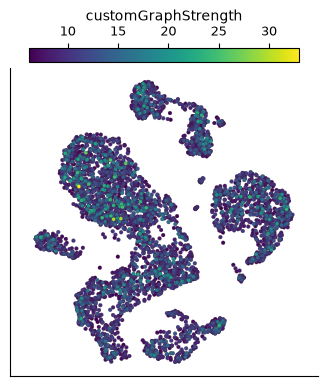

In [3]:
ds.plots.embedding(
    layout_key="RNA_customAnalysisUMAP",
    color_by="customGraphStrength",
    sort_values=True,
)

In [4]:
cell_index = ds.cells.active_index("I")
feature_index = ds.RNA.feats.active_index("I__hvgs")
selected_counts = ds.RNA.rawData[:, feature_index][cell_index, :]

detected_blocks = []
for count_block in selected_counts.stream_blocks(
    nthreads=4,
    msg="Calculating custom detection statistic",
):
    detected_blocks.append(np.count_nonzero(count_block, axis=1))

detected_hvgs = np.concatenate(detected_blocks)
ds.cells.insert(
    column_name="customDetectedHVGs",
    values=detected_hvgs,
    key="I",
    overwrite=True,
)

Calculating custom detection statistic: 2 / 2 complete

In [5]:
well_connected = graph_strength >= np.quantile(graph_strength, 0.25)
ds.cells.insert(
    column_name="wellConnected",
    values=well_connected,
    fill_value=False,
    key="I",
    overwrite=True,
)

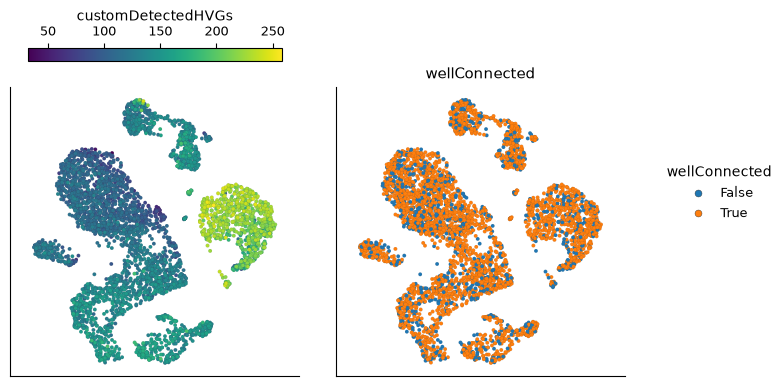

In [6]:
ds.plots.embedding(
    layout_key="RNA_customAnalysisUMAP",
    color_by=["customDetectedHVGs", "wellConnected"],
    n_columns=2,
    sort_values=True,
)

In [7]:
feature_names = ds.RNA.feats.fetch_all("names").astype(str)
panel_mask = np.isin(
    feature_names,
    ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"],
)
custom_feature_key = ds.set_hvgs(
    cell_key="wellConnected",
    mask=panel_mask,
    hvg_key_name="customPanel",
    blacklist="",
)
custom_feature_key

Computing RNA feature statistics: 102 / 102 complete

'wellConnected__customPanel'